In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 (Mac 전용 설정)
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
train = pd.read_csv('../data/train.csv')

# 데이터 크기 확인
print(f"전체 데이터 행(환자 수): {train.shape[0]}명")
print(f"전체 데이터 열(변수 개수): {train.shape[1]}개")

# 상위 5개 데이터 확인
train.head()

전체 데이터 행(환자 수): 256351명
전체 데이터 열(변수 개수): 69개


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


In [6]:
# 칼럼별로 결측치(NaN) 개수와 비율 계산
missing_values = train.isnull().sum()
missing_percentage = (train.isnull().sum() / len(train)) * 100

# 표로 깔끔하게 정리
df_missing = pd.DataFrame({
    '결측치 개수': missing_values,
    '결측치 비율(%)': missing_percentage
}).sort_values(by='결측치 개수', ascending=False)

# 결측치가 있는 칼럼 상위 20개만 출력
print("--- 결측치 상위 20개 칼럼 ---")
display(df_missing.head(20))

--- 결측치 상위 20개 칼럼 ---


,결측치 개수,결측치 비율(%)
난자 해동 경과일,254915,99.439831
PGS 시술 여부,254422,99.247516
PGD 시술 여부,254172,99.149994
착상 전 유전 검사 사용 여부,253633,98.939735
임신 시도 또는 마지막 임신 경과 연수,246981,96.344855
배아 해동 경과일,215982,84.252451
난자 채취 경과일,57488,22.425503
난자 혼합 경과일,53735,20.961494
배아 이식 경과일,43566,16.994667
총 생성 배아 수,6291,2.454057


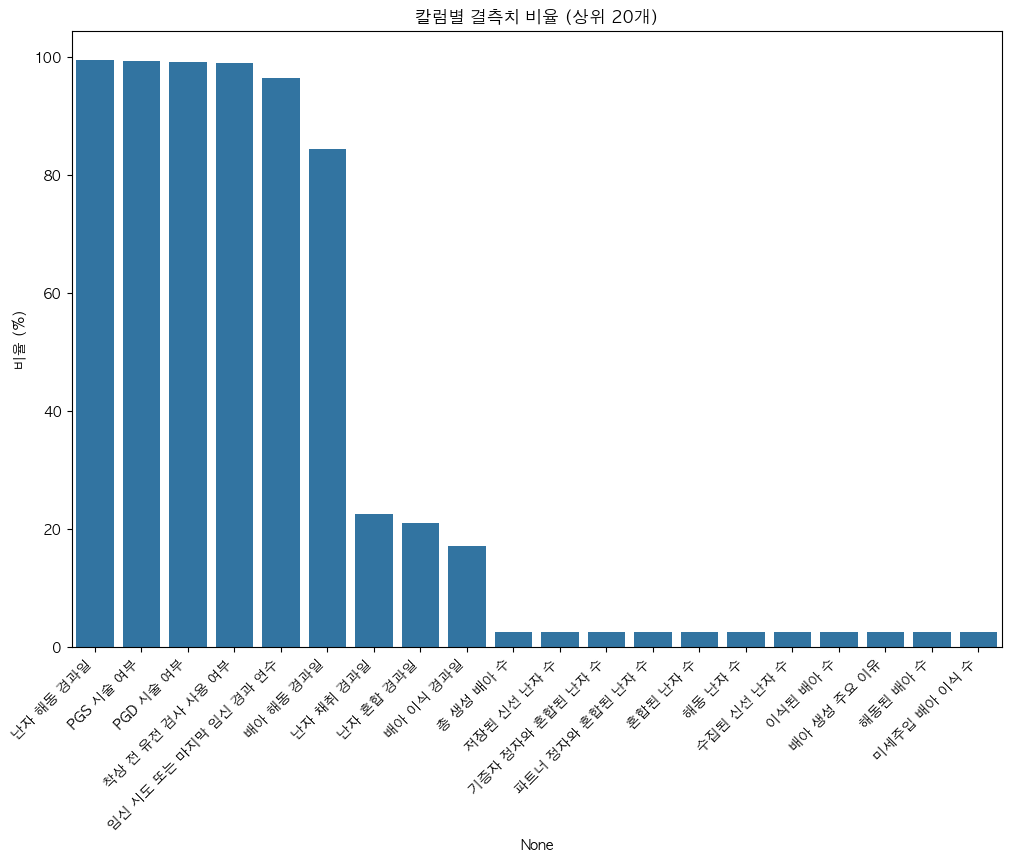

In [7]:
plt.figure(figsize=(12, 8))
sns.barplot(x=df_missing.index[:20], y=df_missing['결측치 비율(%)'][:20])
plt.xticks(rotation=45, ha='right')
plt.title('칼럼별 결측치 비율 (상위 20개)')
plt.ylabel('비율 (%)')
plt.show()

In [8]:
# 1. 결측치가 90% 이상인 칼럼 이름들 뽑아내기
threshold = 90
cols_to_drop = df_missing[df_missing['결측치 비율(%)'] >= threshold].index.tolist()

# 2. 분석에 전혀 도움 안 되는 ID 성격의 칼럼 추가하기
cols_to_drop.extend(['ID', '시술 시기 코드'])

# 3. train 데이터에서 해당 칼럼들 완전히 삭제하기
train_clean = train.drop(columns=cols_to_drop)
test_clean = test.drop(columns=cols_to_drop) # test 데이터도 똑같이 지워줘야 합니다!

# 4. 결과 확인
print(f"🗑️ 삭제된 칼럼 총 {len(cols_to_drop)}개:\n{cols_to_drop}\n")
print(f"✨ 남은 칼럼 개수: train_clean {train_clean.shape[1]}개")

🗑️ 삭제된 칼럼 총 7개:
['난자 해동 경과일', 'PGS 시술 여부', 'PGD 시술 여부', '착상 전 유전 검사 사용 여부', '임신 시도 또는 마지막 임신 경과 연수', 'ID', '시술 시기 코드']

✨ 남은 칼럼 개수: train_clean 62개
